In [2]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pandas as pd
import numpy as np

In [3]:
# ==========================
# (NVDA) NVIDIA - King
# (META) META - AI + Advertising + Metaverse play
# (AVGO) Broadcom - AI chips + semiconductor + VMware
# (LLY) Eli Lilly - GLP-1 (Ozempic competitor) + pharma-AI
# (ASML) ASML Holding - EUV lithography monopoly

tickers = ['NVDA', 'META', 'AVGO', 'LLY', 'ASML']
waktu_berakhir = datetime.now()
waktu_mulai = waktu_berakhir - timedelta(days=5*365)

data_saham = pd.DataFrame()

for ticker in tickers:
    try:
        # Download data for a single ticker
        data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output
        if not data.empty:
            if 'Adj Close' in data.columns:
                data_saham[ticker] = data['Adj Close']
            elif 'Close' in data.columns:
                # Fallback to 'Close' price if 'Adj Close' is not available (e.g., if auto_adjust makes them identical)
                data_saham[ticker] = data['Close']
                print(f"Warning: 'Adj Close' not found for {ticker}, using 'Close' price.")
            else:
                print(f"Could not find 'Adj Close' or 'Close' data for {ticker}.")
        else:
            print(f"No data downloaded for {ticker}.")
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")

/tmp/ipykernel_4789/2606053306.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output


/tmp/ipykernel_4789/2606053306.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output


/tmp/ipykernel_4789/2606053306.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output


/tmp/ipykernel_4789/2606053306.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output


/tmp/ipykernel_4789/2606053306.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output


In [4]:
# Drop any rows with missing values that might occur if some dates are not present for all stocks
data_saham.dropna(inplace=True)

# Tampilkan lima baris pertama dari DataFrame
print("\nData harga saham historis (Close) untuk 5 saham:")
print(data_saham.head())

print("\nInformasi DataFrame:\n")
data_saham.info()


Data harga saham historis (Close) untuk 5 saham:
                 NVDA        META       AVGO         LLY        ASML
Date                                                                
2020-12-10  12.935872  275.422089  36.645840  152.785599  437.610291
2020-12-11  12.976755  271.873932  36.268681  151.874573  432.668304
2020-12-14  13.271427  272.510040  36.803135  149.853241  433.012390
2020-12-15  13.323032  273.861725  37.362595  158.887543  448.603088
2020-12-16  13.205363  273.980988  37.973892  163.271805  450.734772

Informasi DataFrame:

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2020-12-10 to 2025-12-08
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NVDA    1254 non-null   float64
 1   META    1254 non-null   float64
 2   AVGO    1254 non-null   float64
 3   LLY     1254 non-null   float64
 4   ASML    1254 non-null   float64
dtypes: float64(5)
memory usage: 58.8 KB


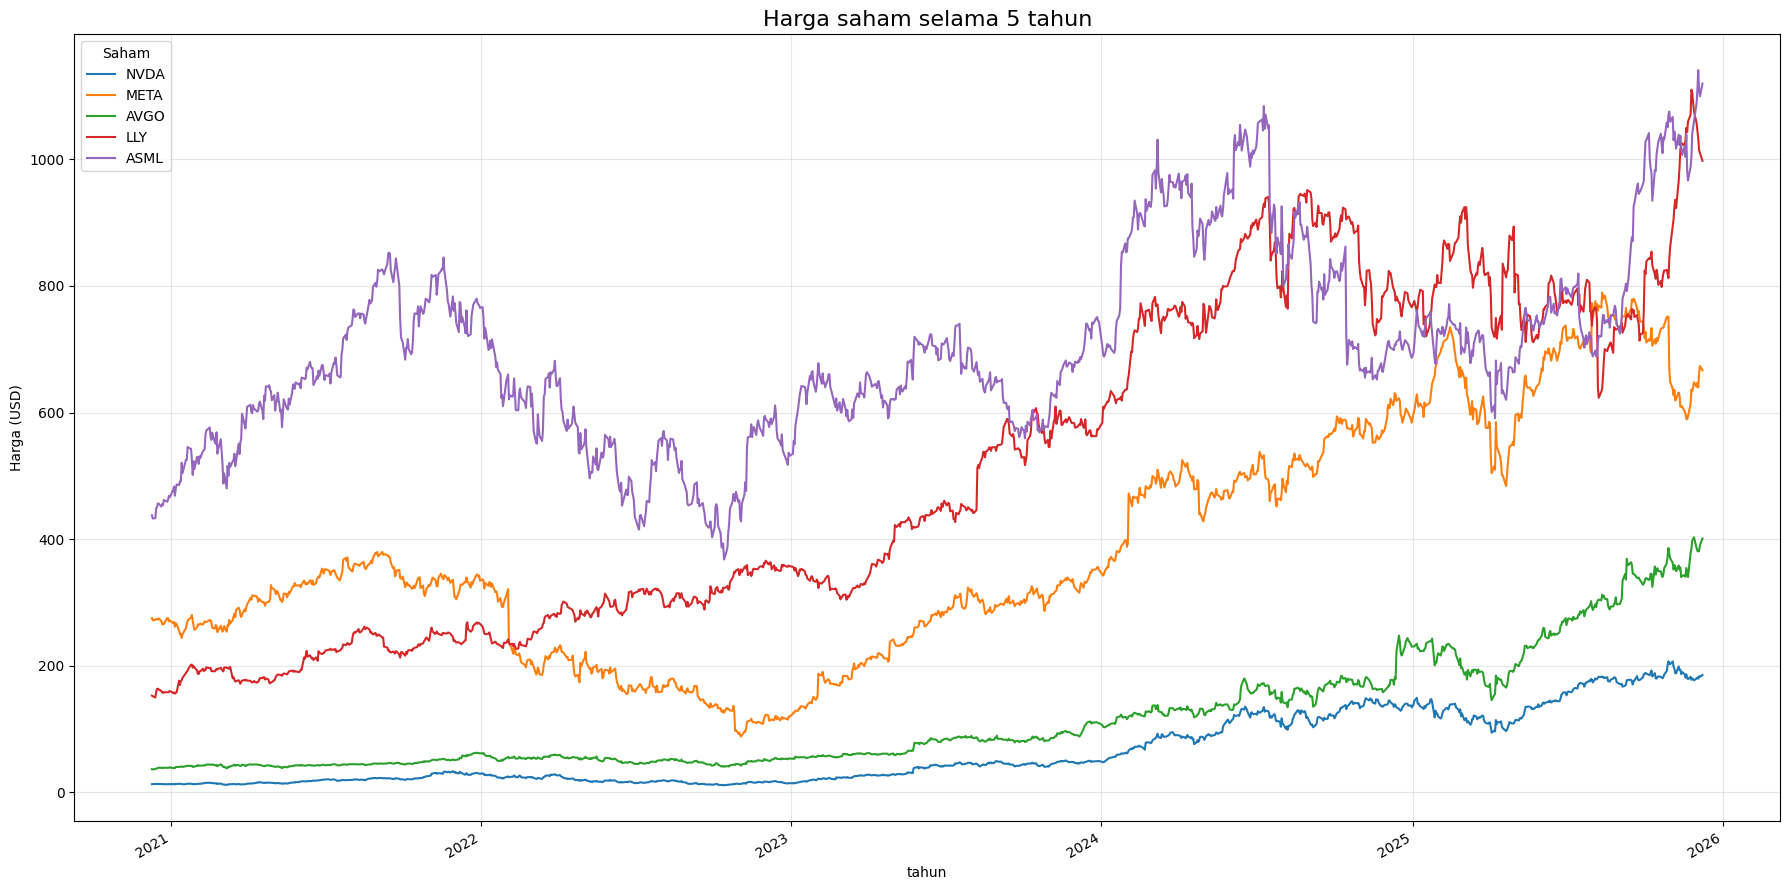

In [5]:
# Plot
plt.figure(figsize=(18, 9))
data_saham.plot(ax=plt.gca())
plt.title('Harga saham selama 5 tahun', fontsize=16)
plt.xlabel('tahun')
plt.ylabel('Harga (USD)')
plt.legend(title='Saham')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# ===========================================================
print("\nInformasi Ringkas DataFrame data_saham:")
data_saham.info()

print("\nStatistik Deskriptif DataFrame data_saham:")
print(data_saham.describe())

print("\nJumlah Nilai Hilang per Kolom di data_saham:")
print(data_saham.isnull().sum())


Informasi Ringkas DataFrame data_saham:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2020-12-10 to 2025-12-08
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NVDA    1254 non-null   float64
 1   META    1254 non-null   float64
 2   AVGO    1254 non-null   float64
 3   LLY     1254 non-null   float64
 4   ASML    1254 non-null   float64
dtypes: float64(5)
memory usage: 58.8 KB

Statistik Deskriptif DataFrame data_saham:
              NVDA         META         AVGO          LLY         ASML
count  1254.000000  1254.000000  1254.000000  1254.000000  1254.000000
mean     65.076830   381.909228   115.192435   508.150743   698.946292
std      56.272168   184.771807    88.653793   260.602889   151.415132
min      11.212904    88.365265    36.268681   149.853241   367.782623
25%      18.900455   235.592648    49.216919   267.174797   599.002365
50%      39.595137   330.338562    78.379967   434.860321   680.3

In [7]:
daily_returns = data_saham.pct_change().dropna()

monthly_returns = data_saham.resample('ME').last().pct_change().dropna()

normalized_stock_data = data_saham / data_saham.iloc[0]

print("\nLima Baris Pertama Daily Returns:")
print(daily_returns.head())

print("\nLima Baris Pertama Monthly Returns:")
print(monthly_returns.head())

print("\nLima Baris Pertama Normalized Stock Data:")
print(normalized_stock_data.head())


Lima Baris Pertama Daily Returns:
                NVDA      META      AVGO       LLY      ASML
Date                                                        
2020-12-11  0.003160 -0.012883 -0.010292 -0.005963 -0.011293
2020-12-14  0.022708  0.002340  0.014736 -0.013309  0.000795
2020-12-15  0.003888  0.004960  0.015201  0.060288  0.036005
2020-12-16 -0.008832  0.000435  0.016361  0.027593  0.004752
2020-12-17  0.007457 -0.004317  0.002824  0.003371  0.012237

Lima Baris Pertama Monthly Returns:
                NVDA      META      AVGO       LLY      ASML
Date                                                        
2021-01-31 -0.004998 -0.054291  0.028891  0.231758  0.095218
2021-02-28  0.055794 -0.002748  0.042997 -0.010696  0.061648
2021-03-31 -0.026369  0.143273 -0.005503 -0.088194  0.088645
2021-04-30  0.124455  0.103724 -0.016089 -0.021679  0.049793
2021-05-31  0.082281  0.011228  0.035357  0.097678  0.045247

Lima Baris Pertama Normalized Stock Data:
                NVDA      META 

## Week 2

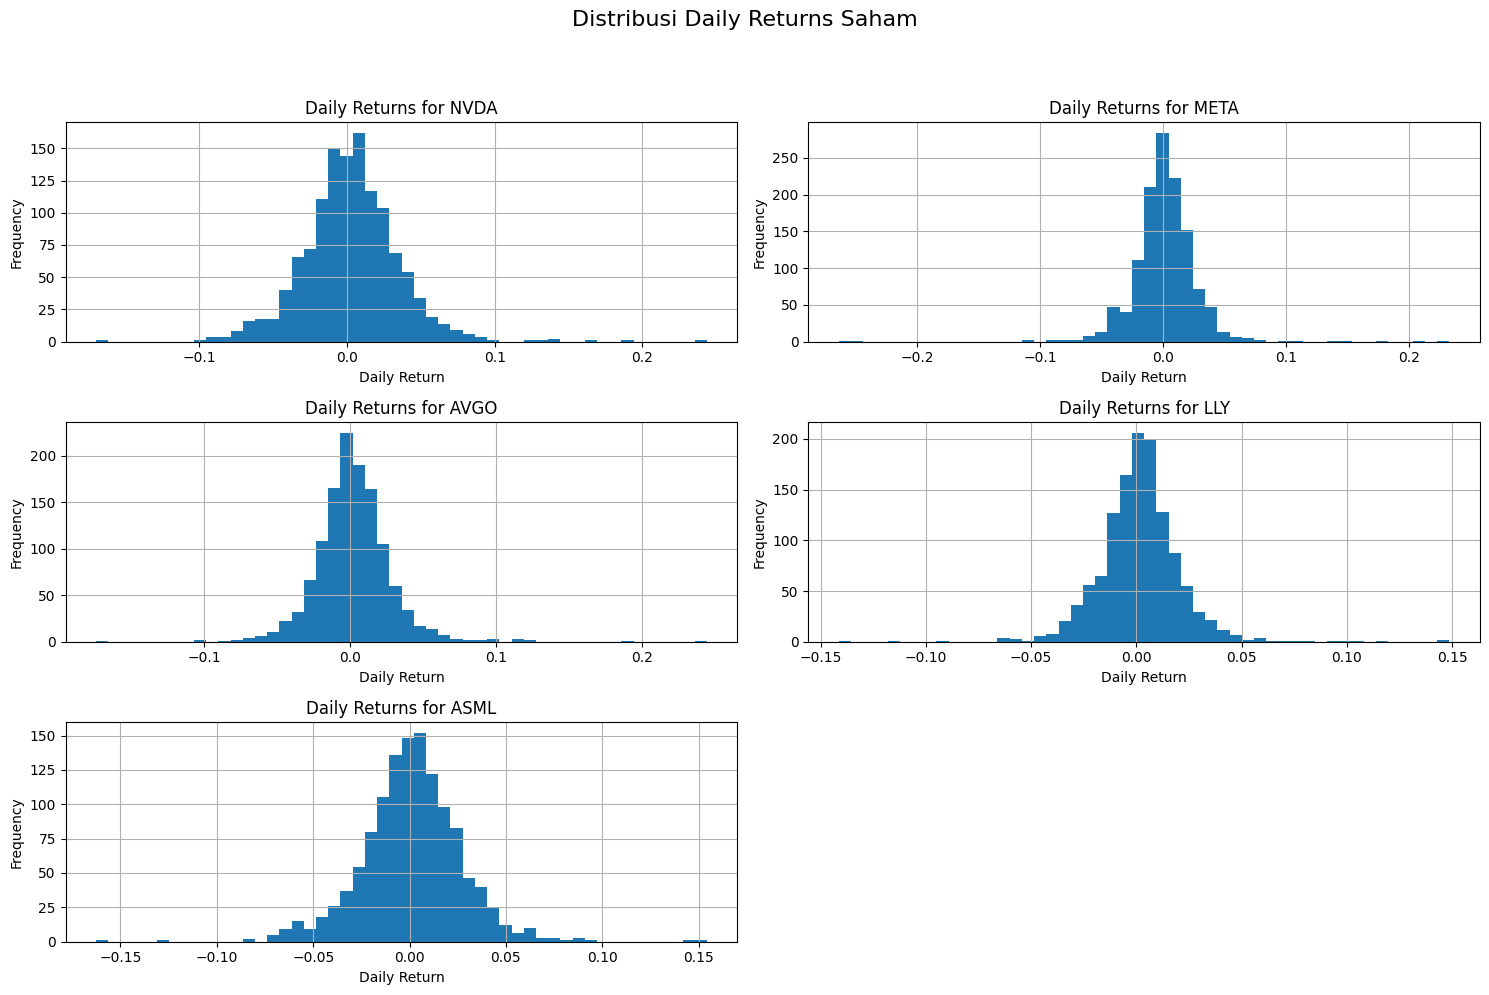

Histograms untuk daily returns telah ditampilkan.


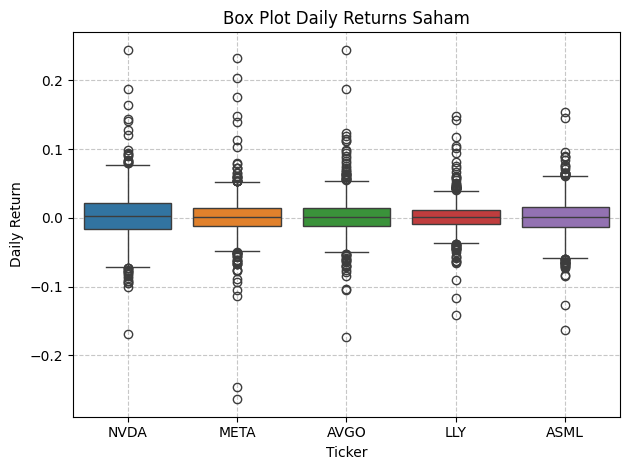

Box plots untuk daily returns telah ditampilkan.


In [8]:
hist_axes = daily_returns.hist(bins=50, figsize=(15, 10))

fig_hist = plt.gcf()
fig_hist.suptitle('Distribusi Daily Returns Saham', y=1.02, fontsize=16)

if isinstance(hist_axes, (list, np.ndarray)) and len(hist_axes.shape) > 1:
    hist_axes = hist_axes.flatten()

for i, ax in enumerate(hist_axes):
    if i < len(daily_returns.columns):
        ax.set_xlabel('Daily Return')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Daily Returns for {daily_returns.columns[i]}')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("Histograms untuk daily returns telah ditampilkan.")

sns.boxplot(data=daily_returns, ax=plt.gca())

plt.title('Box Plot Daily Returns Saham')
plt.xlabel('Ticker')
plt.ylabel('Daily Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Box plots untuk daily returns telah ditampilkan.")

In [9]:
import plotly_express as px

fig_normalized_prices = px.line(
    normalized_stock_data,
    x=normalized_stock_data.index,
    y=normalized_stock_data.columns,
    title='Perbandingan Harga Saham yang Dinormalisasi (Interaktif)',
    labels={'index': 'Tanggal', 'value': 'Harga Dinormalisasi'},
    hover_name=normalized_stock_data.columns.name
)

fig_normalized_prices.update_layout(
    xaxis_title='Tanggal',
    yaxis_title='Harga Dinormalisasi'
)

fig_normalized_prices.show()

print("Line plot interaktif untuk harga saham yang dinormalisasi telah ditampilkan.")

Line plot interaktif untuk harga saham yang dinormalisasi telah ditampilkan.


In [10]:
import plotly_express as px

print("Membuat histogram interaktif untuk daily returns setiap saham...")

for col in daily_returns.columns:
    fig_hist_daily_returns = px.histogram(
        daily_returns,
        x=col,
        nbins=100,
        title=f'Distribusi Daily Returns Interaktif untuk {col}',
        labels={col: 'Daily Return', 'count': 'Frekuensi'}
    )
    fig_hist_daily_returns.update_layout(xaxis_title='Daily Return', yaxis_title='Frekuensi')
    fig_hist_daily_returns.show()

print("Histogram interaktif untuk daily returns telah ditampilkan.")

Membuat histogram interaktif untuk daily returns setiap saham...


Histogram interaktif untuk daily returns telah ditampilkan.


In [11]:
TRADING_DAYS_PER_YEAR = 252
RISK_FREE_RATE = 0.01

cumulative_returns = (1 + daily_returns).prod() - 1

annual_returns = daily_returns.mean() * TRADING_DAYS_PER_YEAR

annualized_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

sharpe_ratios = (annual_returns - RISK_FREE_RATE) / annualized_volatility

portfolio_metrics = pd.DataFrame({
    'Cumulative Return': cumulative_returns,
    'Annual Return': annual_returns,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratios
})

print("Metrik Portofolio untuk Setiap Saham:")
print(portfolio_metrics.round(4))


Metrik Portofolio untuk Setiap Saham:
      Cumulative Return  Annual Return  Annualized Volatility  Sharpe Ratio
NVDA            13.3438         0.6707                 0.5215        1.2668
META             1.4210         0.2733                 0.4345        0.6060
AVGO             9.9453         0.5681                 0.4189        1.3321
LLY              5.5293         0.4287                 0.3206        1.3058
ASML             1.5586         0.2755                 0.4159        0.6385


**Cumulative Return** (Total Pengembalian) Ini mengukur total keuntungan atau kerugian investasi dari awal hingga akhir periode. Rumus: (Harga Akhir dikurang Harga Awal) dibagi Harga Awal. Fungsi: Menunjukkan seberapa banyak uang Anda telah bertumbuh secara keseluruhan. Angka 12.3067 pada NVDA berarti modal Anda naik lebih dari 12 kali lipat.

**Annual Return** (Pengembalian Tahunan) Ini adalah rata-rata keuntungan yang diperoleh setiap tahunnya. Rumus: Dihitung menggunakan rata-rata geometrik (CAGR) untuk memperhitungkan efek bunga berbunga. Fungsi: Membantu Anda membandingkan kinerja aset dengan deposito atau instrumen tahunan lainnya. NVDA memberikan 65,6% per tahun, jauh di atas rata-rata pasar.

**Annualized Volatility** (Volatilitas Tahunan) Ini mengukur seberapa besar harga saham naik dan turun dalam setahun (risiko). Rumus: Standar deviasi dari return harian dikali akar kuadrat dari 252 (jumlah hari perdagangan setahun). Fungsi: Semakin tinggi angka ini, semakin berisiko asetnya. NVDA (52%) lebih berisiko daripada LLY (32%) karena harganya lebih sering bergejolak drastis.

**Sharpe Ratio** (Rasio Efisiensi) Ini mengukur keuntungan yang didapat dibandingkan dengan risiko yang diambil. Rumus: (Return Tahunan dikurang Rate Bebas Risiko) dibagi Volatilitas Tahunan. Fungsi: Menilai kualitas investasi. LLY memiliki skor tertinggi (1.39), artinya ia memberikan keuntungan paling optimal untuk setiap unit risiko yang Anda tanggung. Skor di atas 1 dianggap sangat baik.

## KESIMPULAN SINGKAT

Aset Paling Menguntungkan: NVDA (Return Tahunan 65,62%)

Aset Paling Aman/Stabil: LLY (Volatilitas terendah 32,16%)

Aset Paling Efisien: LLY (Sharpe Ratio tertinggi 1.3914)

Aset Paling Tertinggal: META dan ASML memiliki skor efisiensi terendah dibanding yang lain

## Week 3

In [ ]:
# Asumsikan bobot yang sama untuk setiap saham dalam portofolio
# Anda bisa memodifikasi bobot ini untuk analisis sensitivitas
num_assets = len(tickers)
weights = np.array([1/num_assets] * num_assets)

# Pastikan bobot yang digunakan memiliki indeks kolom yang sama dengan daily_returns
weights_df = pd.Series(weights, index=daily_returns.columns)

# Hitung daily returns portofolio
portfolio_daily_returns = daily_returns.dot(weights)

# Tampilkan lima baris pertama daily returns portofolio
print("Lima Baris Pertama Daily Returns Portofolio:")
print(portfolio_daily_returns.head())

Lima Baris Pertama Daily Returns Portofolio:
Date
2020-12-11   -0.007454
2020-12-14    0.005454
2020-12-15    0.024069
2020-12-16    0.008062
2020-12-17    0.004315
dtype: float64


In [ ]:

# Tetapkan jumlah simulasi portofolio
num_portfolios = 10000 # Contoh: 10.000 atau 20.000

# Inisialisasi daftar kosong untuk menyimpan hasil simulasi
portfolio_returns = []
portfolio_volatility = []
portfolio_sharpe_ratios = []
portfolio_weights = []

# Dapatkan jumlah aset dari daily_returns
num_assets = len(daily_returns.columns)

# Hitung rata-rata return harian dan matriks kovarian
mean_daily_returns = daily_returns.mean()
cov_matrix_daily = daily_returns.cov()

# Loop untuk simulasi
for portfolio in range(num_portfolios):
    # a. Hasilkan bobot acak untuk setiap aset
    weights = np.random.random(num_assets)
    weights = weights / np.sum(weights) # Normalisasi agar jumlahnya 1

    portfolio_weights.append(weights)

    # b. Hitung return portofolio tahunan
    # Annualize mean daily returns first
    annual_returns_individual = mean_daily_returns * TRADING_DAYS_PER_YEAR
    portfolio_annual_return = np.sum(annual_returns_individual * weights)
    portfolio_returns.append(portfolio_annual_return)

    # c. Hitung volatilitas portofolio tahunan
    # Annualize covariance matrix by multiplying by TRADING_DAYS_PER_YEAR
    portfolio_annual_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_daily * TRADING_DAYS_PER_YEAR, weights)))
    portfolio_volatility.append(portfolio_annual_volatility)

    # d. Hitung Sharpe Ratio portofolio
    sharpe_ratio = (portfolio_annual_return - RISK_FREE_RATE) / portfolio_annual_volatility
    portfolio_sharpe_ratios.append(sharpe_ratio)

# Buat DataFrame dari hasil simulasi
portfolio_results = pd.DataFrame({
    'Return': portfolio_returns,
    'Volatility': portfolio_volatility,
    'Sharpe Ratio': portfolio_sharpe_ratios
})

# Tambahkan kolom bobot ke DataFrame
for i, col in enumerate(daily_returns.columns):
    portfolio_results[col + ' Weight'] = [w[i] for w in portfolio_weights]

print("Lima baris pertama hasil simulasi portofolio:")
print(portfolio_results.head())

# Identifikasi portofolio optimal dan risiko minimum
# Portofolio dengan Sharpe Ratio tertinggi
optimal_portfolio = portfolio_results.loc[portfolio_results['Sharpe Ratio'].idxmax()]

# Portofolio dengan volatilitas terendah
min_volatility_portfolio = portfolio_results.loc[portfolio_results['Volatility'].idxmin()]

# Cetak metrik untuk portofolio optimal dan risiko minimum
print("\n======================================================")
print("Portofolio Optimal (Sharpe Ratio Tertinggi):")
print("------------------------------------------------------")
print(f"Annual Return: {optimal_portfolio['Return']:.4f}")
print(f"Annualized Volatility: {optimal_portfolio['Volatility']:.4f}")
print(f"Sharpe Ratio: {optimal_portfolio['Sharpe Ratio']:.4f}")
print("Weights:")
for col in daily_returns.columns:
    print(f"  {col}: {optimal_portfolio[col + ' Weight']:.4f}")
print("======================================================")

print("\n======================================================")
print("Portofolio Risiko Minimum:")
print("------------------------------------------------------")
print(f"Annual Return: {min_volatility_portfolio['Return']:.4f}")
print(f"Annualized Volatility: {min_volatility_portfolio['Volatility']:.4f}")
print(f"Sharpe Ratio: {min_volatility_portfolio['Sharpe Ratio']:.4f}")
print("Weights:")
for col in daily_returns.columns:
    print(f"  {col}: {min_volatility_portfolio[col + ' Weight']:.4f}")
print("======================================================")

Lima baris pertama hasil simulasi portofolio:
     Return  Volatility  Sharpe Ratio  NVDA Weight  META Weight  AVGO Weight  \
0  0.436830    0.318446      1.340352     0.185697     0.146080     0.203069   
1  0.470011    0.308526      1.490994     0.298483     0.134021     0.096577   
2  0.428391    0.340522      1.228678     0.206878     0.099952     0.177007   
3  0.557580    0.337816      1.620941     0.357530     0.019298     0.346600   
4  0.416935    0.336449      1.209499     0.131426     0.243171     0.268891   

   LLY Weight  ASML Weight  
0    0.188195     0.276959  
1    0.317088     0.153830  
2    0.127560     0.388602  
3    0.257268     0.019303  
4    0.073990     0.282522  

Portofolio Optimal (Sharpe Ratio Tertinggi):
------------------------------------------------------
Annual Return: 0.5205
Annualized Volatility: 0.2910
Sharpe Ratio: 1.7542
Weights:
  NVDA: 0.2599
  META: 0.0032
  AVGO: 0.2243
  LLY: 0.5009
  ASML: 0.0117

Portofolio Risiko Minimum:
--------------

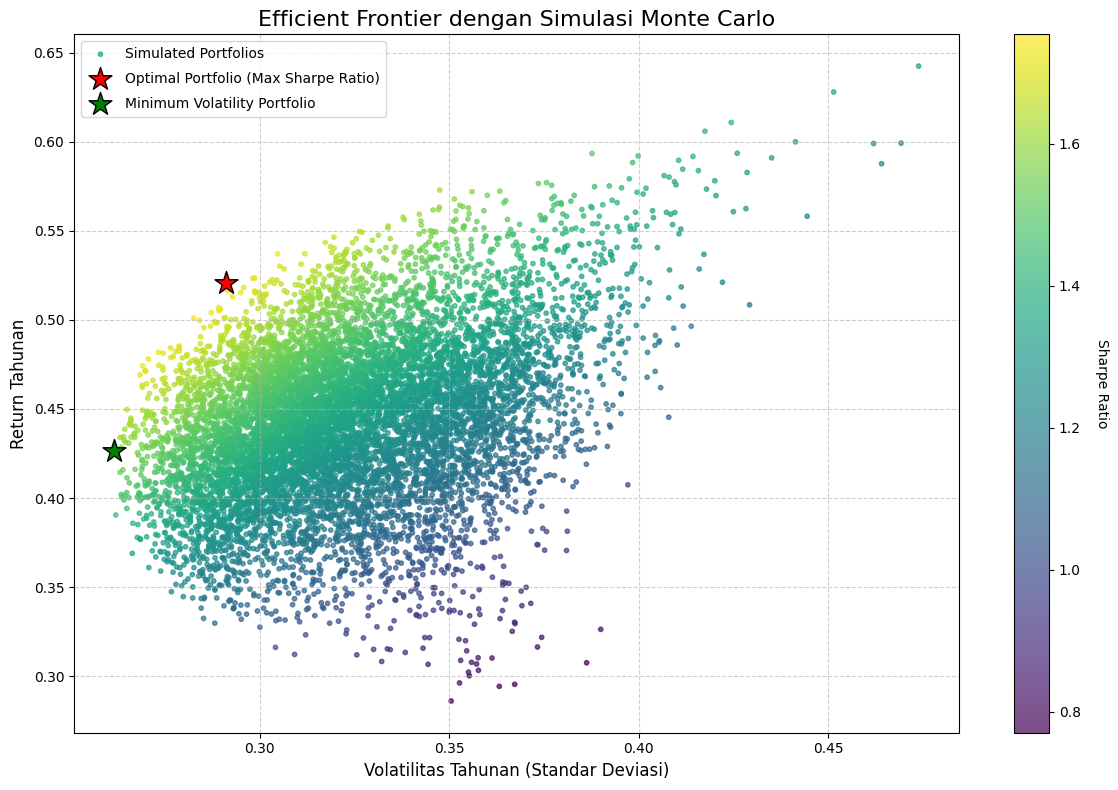

Scatter plot hasil simulasi portofolio telah ditampilkan.


In [14]:

# 1. Buat scatter plot dari semua portofolio yang disimulasikan
plt.figure(figsize=(12, 8))

# Scatter plot untuk semua portofolio
scatter = plt.scatter(
    portfolio_results['Volatility'],
    portfolio_results['Return'],
    c=portfolio_results['Sharpe Ratio'], # Warna berdasarkan Sharpe Ratio
    cmap='viridis', # Colormap
    marker='o',
    s=10, # Ukuran marker
    alpha=0.7,
    label='Simulated Portfolios'
)

# 2. Tandai portofolio optimal (Sharpe Ratio tertinggi)
plt.scatter(
    optimal_portfolio['Volatility'],
    optimal_portfolio['Return'],
    marker='*', # Penanda bintang
    color='red',
    s=300, # Ukuran lebih besar
    label='Optimal Portfolio (Max Sharpe Ratio)',
    edgecolors='black',
    linewidth=1
)

# 3. Tandai portofolio risiko minimum
plt.scatter(
    min_volatility_portfolio['Volatility'],
    min_volatility_portfolio['Return'],
    marker='*', # Penanda bintang
    color='green',
    s=300, # Ukuran lebih besar
    label='Minimum Volatility Portfolio',
    edgecolors='black',
    linewidth=1
)

# 4. Tambahkan judul plot dan label sumbu
plt.title('Efficient Frontier dengan Simulasi Monte Carlo', fontsize=16)
plt.xlabel('Volatilitas Tahunan (Standar Deviasi)', fontsize=12)
plt.ylabel('Return Tahunan', fontsize=12)

# 5. Tampilkan legenda dan grid
plt.legend(labelspacing=0.8, loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

# Tambahkan color bar untuk Sharpe Ratio
cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio', rotation=270, labelpad=20)

# Tampilkan plot
plt.tight_layout()
plt.show()

print("Scatter plot hasil simulasi portofolio telah ditampilkan.")